# 2025-09-04-S2D-Willapa-Mouth-2.ipynb

In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np

f = "/home/cassandra/Willapa/willapa_bathy_liveocean.nc"
nc = xr.open_dataset(f)

depth = -1*nc.h.values.flatten()
lats = nc.lat_rho.values.flatten()
lons = nc.lon_rho.values.flatten()
points = np.array([lons, lats])

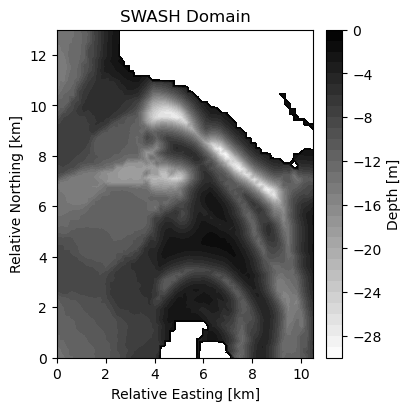

In [2]:
# First add 10 meters to all zero points on the bathy
depth[depth == -0.2] = 10

# Now get a UTM range for the model
import utm

# Convert a lat/lon bounding box to a UTM range
lat0, lon0 = 46.6316, -124.1256
x0, y0, _, __ = utm.from_latlon(lat0, lon0)
lat1, lon1 = 46.7418, -123.98556
x1, y1, _, __ = utm.from_latlon(lat1, lon1)

x1 = x0 + 10500
y1 = y0 + 13000

xrange = np.linspace(x0, x1, 2101)
yrange = np.linspace(y0, y1, 2601)

# Convert each lat/lon pair to utm
xs, ys = [], []
for lat, lon in zip(lats, lons):
    x, y, _, __ = utm.from_latlon(lat, lon)
    xs.append(x)
    ys.append(y)
xy = np.array([xs,ys]).T  # Convert to [N,2] shape

# Interpolate the unstructured bathy onto a grid
import scipy.interpolate
xx, yy = np.meshgrid(xrange, yrange)
zz = scipy.interpolate.griddata(xy, depth, (xx, yy))

# Get an x/y grid in problem coordinates
xp = xrange - xrange[0]
yp = yrange - yrange[0]


# Plot 
plt.figure(figsize=(4,4), constrained_layout=True)
cf = plt.contourf(xp/1000, yp/1000, zz, levels=np.linspace(-30, 0, 31), cmap='binary')
cb = plt.colorbar(cf)
cb.ax.set_ylabel("Depth [m]")
plt.xlabel("Relative Easting [km]")
plt.ylabel("Relative Northing [km]")
plt.title("SWASH Domain")
plt.show()

Alter bathymetry on edges of domain to acommodate sponge layer

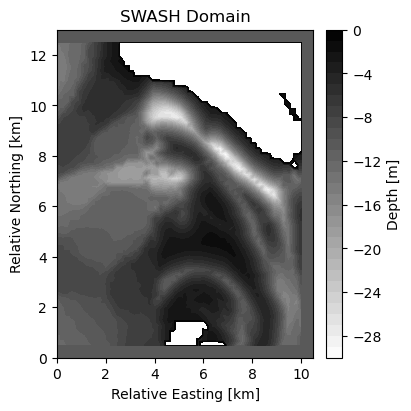

In [3]:
zz[:, xp > 10000] = -10
zz[yp < 500] = -10
zz[yp > 12500] = -10


plt.figure(figsize=(4,4), constrained_layout=True)
cf = plt.contourf(xp/1000, yp/1000, zz, levels=np.linspace(-30, 0, 31), cmap='binary')
cb = plt.colorbar(cf)
cb.ax.set_ylabel("Depth [m]")
plt.xlabel("Relative Easting [km]")
plt.ylabel("Relative Northing [km]")
plt.title("SWASH Domain")
plt.show()

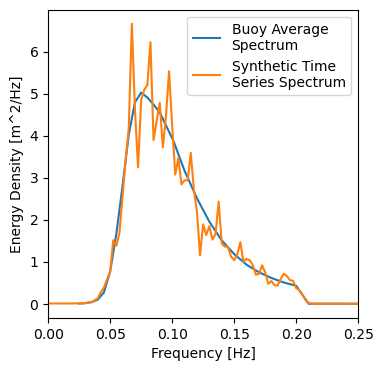

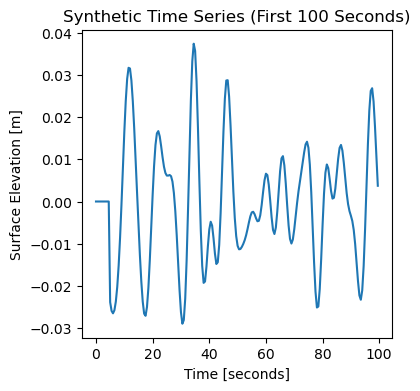

In [4]:
from scipy.fftpack import ifft, fftfreq, fftshift, fft

def psd(a, dt, seg_time=400):
    # Note: NOT NORMALIZED
    # segmenting
    seg_len = int(seg_time / dt)
    seg_indices = range(0, len(a) - int(seg_len), int(seg_len/2))
    seg_a = np.array([cos_taper(a[i:i+seg_len]) for i in seg_indices])
    # Evaluate frequency info
    freq = fftshift(fftfreq(seg_len, d=dt))
    # FFT and go from amplitude to amp^2/Hz
    Fa = fftshift(fft(seg_a, axis=1), axes=1)
    Saa = np.real(np.mean((Fa * np.conj(Fa)), axis=0))
    # Drop negative frequencies
    Saa = Saa[freq >= 0]
    freq = freq[freq >= 0]
    return freq, Saa

def cos_taper(a):
    x = np.linspace(-np.pi/2, np.pi/2, len(a))
    y = np.cos(x)
    tapered = y*a
    t_power = np.std(tapered)**2
    d_power = np.std(a)**2
    return tapered * d_power/t_power
    
# load average buoy spectrum
ncf = '/home/cassandra/Willapa/036p1_rt.nc'
nc = xr.open_dataset(ncf)
cdip_freq = nc.waveFrequency.values
cdip_psd = np.nanmean(nc.waveEnergyDensity.values, axis=0)
cdip_psd[cdip_freq > 0.2] = 0

# Synthetic 1 hour time series based on the spectrum
model_time = 60*60
t = np.arange(0, model_time, 0.5)
f = fftfreq(len(t), d=0.5)
df = f[1]-f[0]
p = np.interp(np.abs(f), cdip_freq, cdip_psd)
coeff = np.sqrt(p * df) * np.exp(1j*np.random.rand(len(f))*2*np.pi)
eta = np.real(ifft(coeff))

# Get rid of gibbs phenomena
eta[:10] = 0
eta[-10:] = 0

# Norm the energy... not sure why I have to do this... 
freq, spec = psd(eta, 0.5, seg_time = 400)
eta = eta * np.sqrt(np.trapezoid(cdip_psd, x=cdip_freq)) / np.sqrt(np.trapezoid(spec, x=freq))
freq, spec = psd(eta, 0.5, seg_time=400)

# # Test energy
plt.figure(figsize=(4,4))
plt.plot(cdip_freq, cdip_psd, label='Buoy Average\nSpectrum')
plt.plot(freq, spec, label='Synthetic Time\nSeries Spectrum')
# plt.loglog()
plt.legend()
plt.xlabel("Frequency [Hz]")
plt.ylabel("Energy Density [m^2/Hz]")
plt.xlim(0, 0.25)
plt.show()

plt.figure(figsize=(4,4))
plt.title("Synthetic Time Series (First 100 Seconds)")
plt.plot(t[:200], eta[:200])
plt.xlabel("Time [seconds]")
plt.ylabel("Surface Elevation [m]")
plt.show()

Need to impose a spectrum with realistic direction and spread at the boundary...


In [7]:
import os

def ensure_dir(path):
    dir = os.path.dirname(path)
    if not os.path.exists(dir):
        os.makedirs(dir)

ensure_dir('/home/cassandra/Willapa/SWASH2D-test-6/')
os.chdir('/home/cassandra/Willapa/SWASH2D-test-6/')

In [8]:
import pandas as pd

# How many grid cells in x,y
mxc = len(xp) - 1
myc = len(yp) - 1

# I prefer things in problem coordinates
xx, yy = np.meshgrid(xp, yp)

# Coordinates / Grid file
grid_data = {}
for i in range(mxc+1):
    grid_data.update({i:np.append(xx[:,i], yy[:,i])})
grid_2d_df = pd.DataFrame.from_dict(grid_data)
grid_2d_df.to_csv('coords.txt', sep=' ', header=False, index=False)

# Bathy
bot_2d_df = pd.DataFrame.from_dict({str(i):np.around(zz[:,i],1) for i in range(mxc+1)})
bot_2d_df.to_csv('bathy.txt', sep=' ', header=False, index=False)    

In [9]:
# Method for converting time (in seconds) to a format SWASH input likes
def format_time(t):
    hours = int(t/3600)
    minutes = int(t/60 % 60)
    seconds = int(t % 60)
    ms = int(1000*(t % 1))
    return str(hours).zfill(2) + str(minutes).zfill(2) + str(seconds).zfill(2) + '.' + str(ms).zfill(3)

# Time series file    
# file_content = ""
# for j in range(len(t)):
#     file_content += format_time(t[j]) + ' ' + "{:.7f}".format(np.around(eta[j], 8)) + '\n'
# with open('bc.txt', 'w') as file:
#     file.write(file_content)

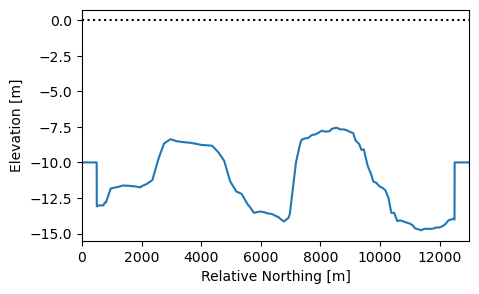

In [10]:
plt.figure(figsize=(5,3))
plt.plot(yp, zz[:,0])
plt.xlim(0, 13000)
plt.axhline(0, color='black', linestyle=':')
plt.xlabel("Relative Northing [m]")
plt.ylabel("Elevation [m]")
plt.show()

In [14]:
bc_str = "BOUN SEGMENT XY 0 0 0 12000 BTYPE WEAKrefl CON SERIes 'bc.txt' 7"

bc_str = """
BOUnd SHAPespec JONswap 3.3 SIG PEAK DSPR DEGRees
BOUndcond SEGMent XY 0 500 0 12500 BTYPE WEAKrefl CONstant SPECTrum 2.2 13.3 0 20 3 HR
SPONgelayer E 500
SPONgelayer S 500
SPONgelayer N 500
"""

In [15]:
model_time = 60*60*2
hours, minutes, seconds = int(model_time/3600), int(model_time/60 - 60*int(model_time/3600)), model_time%60
timestr = "{hours:02d}{minutes:02d}{seconds:02d}.000".format(hours=hours, minutes=minutes, seconds=seconds)

In [16]:
template = """
$
$*************** INPUT *********************
$
PROJ 'default' '01'
MODE NONSTationary TWODimensional
$
CGRID CURV {mxc} {myc}
READgrid COORdinates 1 'coords.txt' 1 0 0 FREE
VERT 1
INPgrid BOTtom CURV EXCeption -10.0
READinp BOTtom -1 'bathy.txt' 1 0 FREE
SET depmin = 0.010
SET level = 0
{bc_str}
$
$*************** PHYSICS *********************
$
FRIC MANN 0.019
SET BACKVISC 1.e-4
BREAK 0.6 0.3
VISC VERT KEPS
$
$*************** NUMERICS *********************
$
NONHYDROSTATIC BOX 1. PRECONDITIONER ILU
DISCRET CORRDEP MUSCL 
DISCRET UPW UMOM MOM VERT FIR
DISCRET UPW UMOM MOM HOR MUSCL
DISCRET UPW WMOM VERT FIR
DISCRET UPW WMOM HOR MUSCL
TIMEI 0.4 0.8
$
$************ OUTPUT REQUESTS *************************  
$
FRAME 'reduced' 0 500 0 10000 12500 300 400 
BLOCK 'reduced' NOHEAD 'eta.mat' XP YP BOTL WATL OUTPUT 000000.000 2.0 SEC
BLOCK 'reduced' NOHEAD 'u.mat' XP YP BOTL VKSI OUTPUT 000000.000 2.0 SEC
BLOCK 'reduced' NOHEAD 'v.mat' XP YP BOTL VETA OUTPUT 000000.000 2.0 SEC

$ BLOCK 'COMPGRID' NOHEAD 'output.mat' XP YP BOTL WATL VKSIK VETAK HK OUTPUT 000000.000 1.0 SEC

TEST 1 0
COMPUTE 000000.000 0.1 SEC {timestr}
STOP
"""


ini_string = template.format(mxc=mxc, myc=myc, timestr=timestr, bc_str=bc_str,
                            xmax=max(xp), ymax=max(yp), n=400, m=400)
input_file = open('INPUT', "w")
input_file.write(ini_string)
input_file.close()

/home/cassandra/anaconda3/lib/python3.13/site-packages/scipy/io/matlab/_mio.py:235: MatReadWarning: Duplicate variable name "Xp" in stream - replacing previous with new
Considerscipy.io.matlab.varmats_from_mat to split file into single variable files
  matfile_dict = MR.get_variables(variable_names)
/home/cassandra/anaconda3/lib/python3.13/site-packages/scipy/io/matlab/_mio.py:235: MatReadWarning: Duplicate variable name "Yp" in stream - replacing previous with new
Considerscipy.io.matlab.varmats_from_mat to split file into single variable files
  matfile_dict = MR.get_variables(variable_names)
/home/cassandra/anaconda3/lib/python3.13/site-packages/scipy/io/matlab/_mio.py:235: MatReadWarning: Duplicate variable name "Botlev" in stream - replacing previous with new
Considerscipy.io.matlab.varmats_from_mat to split file into single variable files
  matfile_dict = MR.get_variables(variable_names)


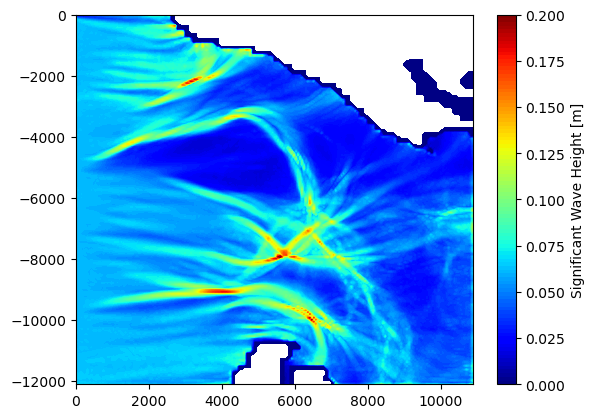

In [38]:
maf = '/home/cassandra/Willapa/SWASH2D-test-3/output.mat'
m = scipy.io.loadmat(maf)

# Time series data types
# didnt work for some reason
dtypes = ['Watlev'] 

# 3.b. Get x and y coordinates. For some reason, y is flipped, so flip it back.
x = np.unique(m['Xp'])
y = np.unique(m['Yp'])

# 3.c.1: Parse each key to grab the timestamp
t = []
for key_str in list(m.keys())[6:]:
    key_str_split = key_str.split('_')
    milliseconds = np.timedelta64( int(key_str_split[-1]),         'ms')
    seconds      = np.timedelta64( int(key_str_split[-2][-2:]),    's')
    minutes      = np.timedelta64( int(key_str_split[-2][-4:-2]),  'm')
    hours        = np.timedelta64( int(key_str_split[-2][-6:-4]),  'h')
    td = np.timedelta64(hours + minutes + seconds + milliseconds)
    t.append(td)
t = np.unique(t)
t = np.array(t).astype('timedelta64[ms]')

eta = []
lists = [eta] 
for key_str in list(m.keys())[3:]:
    for d, l in zip(dtypes, lists):
        if d in key_str:
            l.append(m[key_str])
            
eta = np.array(eta)
z_bottom = m['Botlev']

Hs = 4*np.nanstd(eta, axis=0)
Hs[z_bottom == -10] = np.nan

plt.figure()
cf = plt.contourf(x, -1*y, Hs, np.linspace(0, 0.2, 101), cmap='jet')
cb = plt.colorbar(cf, ticks=np.linspace(0, 0.2, 9))
cb.ax.set_ylabel("Significant Wave Height [m]")
plt.show()

In [34]:
F_eta = fft(eta, axis=0)
freq = fftfreq(len(eta), d=1.0)
is_ig = np.logical_and(np.abs(freq) >= 0.004, np.abs(freq) <= 0.04)
F_eta[~is_ig] = 0
eta_ig = ifft(F_eta, axis=0)
Hig = 4*np.nanstd(eta_ig, axis=0)
Hig[z_bottom == -10] = np.nan

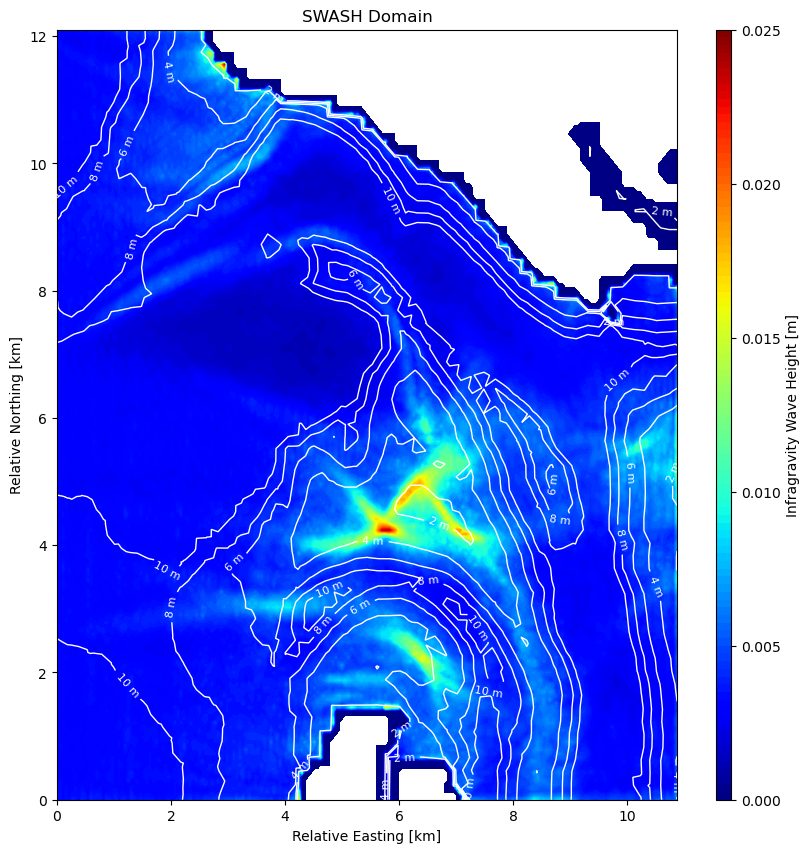

In [35]:
plt.figure(figsize=(10,10))
cf = plt.contourf(x/1000, np.flip(y)/1000, Hig, np.linspace(0, 0.025, 101), cmap='jet')
cb = plt.colorbar(cf, ticks=np.linspace(0, 0.025, 6), aspect=50)
cb.ax.set_ylabel("Infragravity Wave Height [m]")
cs = plt.contour(xp/1000, yp/1000, -1*zz, levels=[2, 4, 6, 8, 10], linewidths=1, colors='white')
plt.clabel(cs, cs.levels, fontsize=8, fmt=lambda s : str(int(s)) + " m")
plt.xlabel("Relative Easting [km]")
plt.ylabel("Relative Northing [km]")
plt.title("SWASH Domain")
plt.show()

In [ ]:
t = t.astype('timedelta64[s]')
y = np.flip(y)

from matplotlib import animation

fig = plt.figure(figsize=(10,10), constrained_layout=True)
ax = plt.subplot(111)
cs = plt.contour(xp/1000, yp/1000, -1*zz, levels=[2, 4, 6, 8, 10], linewidths=1, colors='white')
plt.clabel(cs, cs.levels, fontsize=8, fmt=lambda s : str(int(s)) + " m")
plt.xlabel("Relative Easting [km]")
plt.ylabel("Relative Northing [km]")
plt.title("SWASH Domain")
mesh = ax.pcolormesh(x/1000, y/1000, eta[0], cmap='seismic', vmin=-0.5, vmax=0.5, shading='nearest')
cb = plt.colorbar(mesh, aspect=50)
cb.ax.set_ylabel("Surface Anomaly [m]")
title = plt.title(str(t[0])[0:16])
plt.close()

def animate(i):
    mesh.set_array(eta[i].ravel())
    title.set_text(str(t[i])[0:16])
    return mesh, title
anim = animation.FuncAnimation(fig, animate, frames=range(2, 1800), blit=True, interval=100)

from IPython.display import HTML
HTML(anim.to_html5_video())